In [5]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
import seaborn as sns
import pandas as pd 
pd.set_option("display.max_columns", None)      # view ALL columns in DataFrames
# pd.reset_option("display.max_columns")        # reset to default
from pypalettes import load_cmap
from drawarrow import ax_arrow
from highlight_text import fig_text
# personalisation
plt.rcParams.update({
    "font.family": "Georgia",
    "font.size": 11,
    "lines.linewidth": 1,
})

# Import Data

In [6]:
df = pd.read_parquet("../data/strava_activities.parquet")

keep = [
    "activity_id", "name", "type",
    "start_datetime", "end_datetime",
    "date", "month", "weekday", "start_hour",
    "distance_km", "distance_miles",
    "moving_time_mins", "elapsed_time_mins",
    "avg_pace_km", "avg_pace_mile",
    "avg_hr", "max_hr", "avg_cadence_spm",
    "total_elev_gain",
    "shoe", "num_comments", "num_achievements", "num_kudos"
]

df = df[keep]

df.sample(n=5)

,activity_id,name,type,start_datetime,end_datetime,date,month,weekday,start_hour,distance_km,distance_miles,moving_time_mins,elapsed_time_mins,avg_pace_km,avg_pace_mile,avg_hr,max_hr,avg_cadence_spm,total_elev_gain,shoe,num_comments,num_achievements,num_kudos
528,11235337342,Near Fucking Hopeless,Run,2024-04-21 21:30:23+00:00,2024-04-21 23:20:57+00:00,2024-04-21,April,Sunday,21,13.1912,8.196629,103.966667,110.566667,7.880221,12.681965,160.1,183.0,NaN,22.3,None,0,3,0
452,9648249184,60 mins (146 bpm),Run,2023-08-14 21:18:48+00:00,2023-08-14 22:20:08+00:00,2023-08-14,August,Monday,21,7.7853,4.837560,60.500000,61.333333,7.770008,12.504595,NaN,NaN,NaN,25.1,None,0,3,1
709,14614723881,9K (160 bpm),Run,2025-05-27 21:24:19+00:00,2025-05-27 22:23:01+00:00,2025-05-27,May,Tuesday,21,9.0307,5.611415,58.700000,58.700000,6.500260,10.461137,160.3,175.0,165.4,26.2,Nike Invincible Run 3,0,1,0
788,16499681806,9K (156 bpm),Run,2025-11-18 21:51:15+00:00,2025-11-18 22:54:26+00:00,2025-11-18,November,Tuesday,21,9.0150,5.601660,63.183333,63.183333,7.008691,11.279376,156.3,165.0,162.4,28.5,Nike Invincible Run 3,0,0,0
425,9389851224,60 mins (153 bpm),Run,2023-07-04 21:53:43+00:00,2023-07-04 22:54:33+00:00,2023-07-04,July,Tuesday,21,7.9215,4.922190,60.616667,60.833333,7.652280,12.315131,NaN,NaN,NaN,20.4,Nike Air Zoom Pegasus 29,0,13,1


# Kernel Density Estimation (KDE) Plot

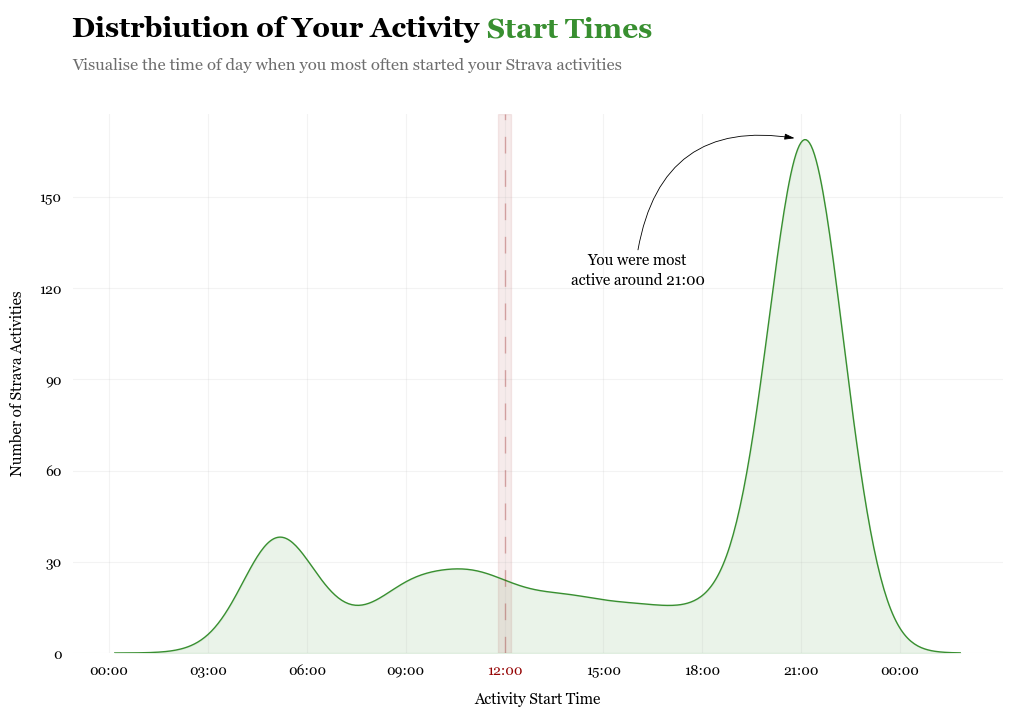

In [7]:
# choose colours
midday_colour = "#950404FF"
line_colour = "#388F30FF"

# create a figure for visualisation
fig, ax = plt.subplots(figsize=(12, 7))

# axes customisation
ax.spines[["top", "right", "bottom", "left"]].set_visible(False)    # remove all plot borders
ax.grid(True, alpha=0.15)                                           # add a light background grid   
ax.tick_params(length=0, pad=8, labelsize=10)

# axis ticks spacing
x_range = np.arange(0, 25, 3)
ax.set_xticks(x_range)

# hardcode the 24:00 label as 00:00
xtick_labels = [f"{int(x_range[i]):02d}:00" for i in range(len(x_range) - 1)] + [f"00:00"]
ax.set_xticklabels(xtick_labels)
ax.set_xlabel("Activity Start Time", labelpad=10)
ax.set_ylabel("Number of Strava Activities", labelpad=10)

# plot KDE from seaborn
sns.kdeplot(
    data=df,
    x="start_hour",
    ax=ax,
    color=line_colour,
    bw_adjust=0.6,          # bandwidth: higher = smoother
    # clip=(0, 24),
    gridsize=500,           # no. of data points to construct line
    linewidth=1,
)

# get KDE line x and y values data
line = ax.lines[len(ax.lines) - 1]      # index is the last made line
x_kde, y_kde = line.get_xdata(), line.get_ydata()

# scale KDE y values to counts
y_kde_scaled = y_kde * df.shape[0] * 1   # scale by total count and bin width

# remove KDE line and create new scaled line plot
line.remove()
ax.plot(x_kde, y_kde_scaled, color=line_colour, linewidth=1)
ax.set_ylim(bottom=0)
ax.yaxis.set_major_locator(MaxNLocator(nbins=6))

# find the peak point
peak_idx = np.argmax(y_kde)
x_peak, y_peak = x_kde[peak_idx], y_kde_scaled[peak_idx]

# fill under KDE line plot
ax.fill_between(
    x=x_kde,
    y1=0, 
    y2=y_kde_scaled,
    alpha=0.1,
    color=line_colour
)

# shaded band around noon
ax.axvspan(11.8, 12.2, color=midday_colour, alpha=0.08)
ax.axvline(
    x=12,
    linestyle=(0, (12, 12)),
    color=midday_colour,
    alpha=0.3
)

# colour only the midday (12:00) tick label
for label, tick in zip(ax.get_xticklabels(), x_range):
    if tick == 12:
        label.set_color(midday_colour)
        # label.set_fontweight("bold")   

# arrow: point to the peak
x_tail, y_tail = x_peak * .76, y_peak * .78
ax_arrow(
    head_position=(x_peak * .99, y_peak * 1.002),
    tail_position=(x_tail, y_tail),
    fill_head=True,
    head_width=1.8,
    head_length=6,
    color="black",
    radius=-0.5,
    width=0.6
)

# annotation text: state peak activity 
ax.text(
    x=x_tail, y=y_tail * 0.955,
    # s=f"the majority of\nyour activites started\naround {x_peak:.0f}:00",
    s=f"You were most\nactive around {x_peak:.0f}:00",    
    ha="center",
    va="center",
    fontsize=11,
    linespacing=1.45
)

# chart title
x_value, y_value = 0.125, 1.02
fig_text( 
    x=x_value, y=y_value, 
    s=f"Distrbiution of Your Activity <Start Times>", 
    highlight_textprops=[
        {"color": line_colour, "weight": "bold"},
    ], 
    fontsize=20,
    weight="bold"
)

# chart subtitle
fig.text(
    x=x_value,
    y=y_value * 0.925,
    s="Visualise the time of day when you most often started your Strava activities",
    size=12,
    color="#6e6e6e"
)

# save figure as SVG
plt.savefig("../images/activity_start_time_kde.svg", bbox_inches="tight")

plt.show()